In [1]:
import sys
sys.path.append('..')  # repo root, one level up from notebooks/

import numpy as np
import matplotlib.pyplot as plt
from src.pricing.binomial_tree import multistep
from src.utils.option_properties import Option

# Testing the multistep function

In [2]:
opt = Option(
    S_0 = 100,
    K = 100,
    r = 0.05,
    T = 1,
    sigma = 0.2,
    n = 500
)

multistep(opt)

np.float64(10.44658513644654)

# Plotting price vs n

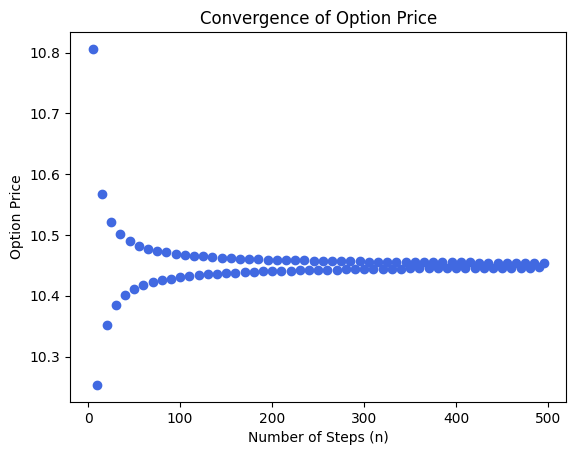

In [3]:
ns = range(5,500,5)
prices = []
for n in ns:
    opt = Option(
        S_0 = 100,
        K = 100,
        r = 0.05,
        T = 1,
        sigma = 0.2,
        n = n
    )
    price = multistep(opt)
    prices.append(price)

plt.scatter(ns, prices, c = 'royalblue')
plt.xlabel("Number of Steps (n)")
plt.ylabel("Option Price")
plt.title("Convergence of Option Price")
plt.show()

# Price vs maturity to time

I want to include American puts

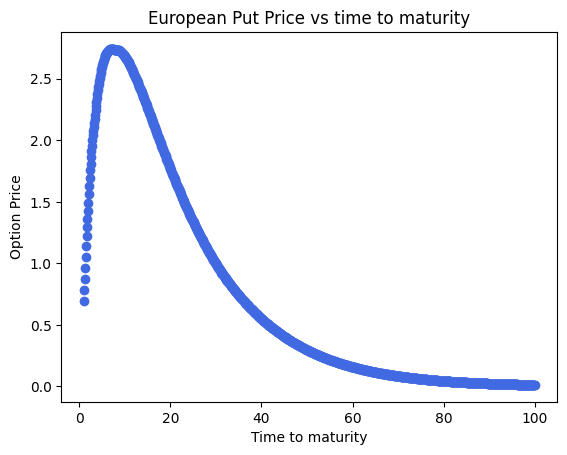

In [4]:
T = np.linspace(1,100,1000)
prices = []
for x in T:
    opt = Option(
        S_0 = 100,
        K = 80,
        r = 0.05,
        T = x,
        sigma = 0.2,
        n = 100
    )
    price = multistep(opt,option_class="put")
    prices.append(price)

plt.scatter(T, prices, c = 'royalblue')
plt.xlabel("Time to maturity")
plt.ylabel("Option Price")
plt.title("European Put Price vs time to maturity")
plt.show()

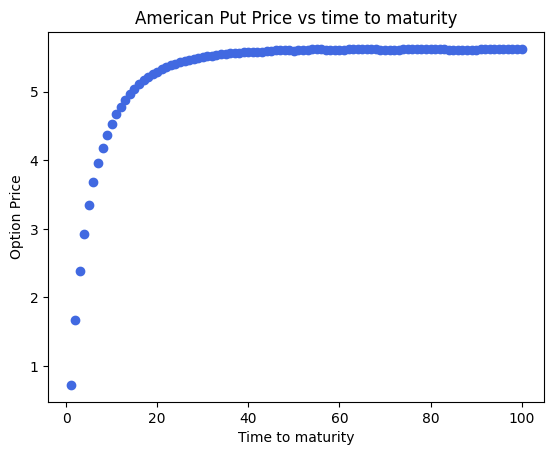

In [5]:
T = np.linspace(1,100,100)
prices = []
for x in T:
    opt = Option(
        S_0 = 100,
        K = 80,
        r = 0.05,
        T = x,
        sigma = 0.2,
        n = 1000
    )
    price = multistep(opt,option_class="put",option_type="American")
    prices.append(price)

plt.scatter(T, prices, c = 'royalblue')
plt.xlabel("Time to maturity")
plt.ylabel("Option Price")
plt.title("American Put Price vs time to maturity")
plt.show()